# Post-hoc inference on Baseline checkpoints

Inference-only comparison on frozen checkpoints. **No model is retrained.**

Every inference rule is one cell of a **readout x transform** grid, and the same four cells are evaluated for every model:

|  | `node_score` | `subspace_norm` |
|---|---|---|
| **no transform** | rank each node by its own coordinate | rank it by the L2 norm over its ancestors+self+descendants subspace |
| **HCC projection** | `hcc_node_score` | `hcc_subspace_norm` |

Each checkpoint's own inference is one of these cells — `node_score` for H-CAST, HT-CapsNet and HRN, `subspace_norm` for Hier-COS, and the HCC-prefixed cell for a checkpoint trained with HCC — so the comparison asks one question of every model: **does aggregating over the taxonomy subspace, or projecting onto the hierarchy constraint, beat what the model already does?**

`subspace_norm` aggregates each model's **own per-level probabilities**, not raw logits, because an L2 norm is not invariant to a monotone map: `‖f(z)‖` is not a monotone function of `‖z‖`. Softmax for H-CAST and HT-CapsNet, sigmoid/sigmoid/softmax for HRN, identity for Hier-COS, whose training already drives non-target coordinate magnitudes to ~0. `node_score` is unaffected, since every one of those activations is monotone and cannot change a per-level argmax. Set `SUBSPACE_SCORE_SPACE = 'coordinate'` to reproduce raw-logit results.

**This notebook covers one training mechanism: baseline** — plain hierarchical training: no gradient-space projection and no output-space constraint. It is the reference every other mechanism is compared against, so the gains below are what a readout buys on top of ordinary training.

The key quantity here is the within-checkpoint **gain against that checkpoint's native cell**: the two rows come from one set of weights, so the only thing that differs is the inference rule. Positive always means the listed cell is better, including for the lower-is-better AHD and TICE. Every completed seed is evaluated separately; its YAML stays in that seed's run directory, and tables and plots report mean ± sample standard deviation with the seed count.

> To compare **mechanisms against each other** at any inference cell — HCC read with `hcc + subspace` against the baseline read with `subspace`, say — use [`all_mechanics.ipynb`](all_mechanics.ipynb). That comparison is not within-checkpoint and carries its own caveat, which is why it lives in its own notebook.

## Experimental cautions

1. H-CAST/HT-CapsNet/HRN coordinates were not trained as Hier-COS coordinates; identity-frame decoding is a post-hoc assumption.
2. The available best checkpoints were selected using each model's native validation inference. This can favor native inference.
3. Top-down and independent rows must use their corresponding best checkpoints. This notebook preserves that rule (`MATCHED_CHECKPOINT`).
4. Unequal seed coverage must be reported. A one-seed sign is suggestive, not robust evidence.
5. Treat this test-set analysis as a pre-specified ablation. Do not tune normalization or score variants repeatedly on test data.

In [1]:
import sys
from pathlib import Path

import pandas as pd

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'evaluation').is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / 'evaluation').is_dir(), 'Run this notebook from inside the repository.'
if str(REPO_ROOT / 'notebooks' / 'utils') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'notebooks' / 'utils'))

import posthoc_inference_utils as posthoc

# ---- what to evaluate ----------------------------------------------------
EXPERIMENT_FAMILY = 'baseline'      # this notebook covers exactly one mechanism
DATASETS = posthoc.DATASETS         # ('cifar100', 'cub200', 'aircraft')
RUN_EVALUATION = True               # the evaluation cell runs the checkpoint evaluator
OVERWRITE = False                   # True re-runs runs that already have a result file
DEVICE = None                       # None: cuda when available, else cpu
# 'all' evaluates the complete readout x transform grid; 'both' restricts it to
# node_score and subspace_norm. HCC-trained checkpoints need 'all' for their own
# native cell to be present.
INFERENCE_MODE = 'all'
# Space `subspace_norm` aggregates: 'probability' (default) or 'coordinate'.
SUBSPACE_SCORE_SPACE = 'probability'

# ---- figure settings -----------------------------------------------------
posthoc.THESIS_STYLE = True         # False puts the title and note back inside the image
posthoc.TEXT_WIDTH_IN = 6.3         # \the\textwidth of the thesis, in inches
SAVE_PLOTS = True
PLOT_OUTPUT_DIR = (posthoc.OUTPUTS_ROOT / 'analysis' / 'inference_analysis'
                   / EXPERIMENT_FAMILY)

print(f'Mechanism: {EXPERIMENT_FAMILY} — '
      f'{posthoc.FAMILY_DESCRIPTIONS[EXPERIMENT_FAMILY]}')
print('Figures ->', PLOT_OUTPUT_DIR if SAVE_PLOTS else 'not saved')

Mechanism: baseline — plain hierarchical training, no gradient-space or output-space constraint
Figures -> /scratch/g.saggini1/outputs/analysis/inference_analysis/baseline


/home/g.saggini1/lexicographic_deep_learning_detailed_study/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Completed runs for this mechanism: a run counts only if it has both
# validation-selected checkpoints, so a partial run never enters a mean.
run_table = posthoc.discover_runs(EXPERIMENT_FAMILY, datasets=DATASETS)
display(posthoc.coverage_table(run_table))

,family,dataset_slug,model,runs,evaluated
0,baseline,aircraft,hcast,3,3
1,baseline,aircraft,hiercos,3,3
2,baseline,aircraft,hrn,3,0
3,baseline,aircraft,htcapsnet,1,0
4,baseline,cifar100,hcast,3,3
5,baseline,cifar100,hiercos,3,3
6,baseline,cifar100,hrn,3,0
7,baseline,cifar100,htcapsnet,1,0
8,baseline,cub200,hcast,3,3
9,baseline,cub200,hiercos,3,3


In [3]:
# Run this cell from one kernel at a time: the evaluator checks for an existing
# output before it starts and again when it saves, so a second concurrent copy of
# the sweep makes whichever process is slower fail at save time.
result_files = posthoc.evaluate_runs(
    run_table,
    run_evaluation=RUN_EVALUATION,
    overwrite=OVERWRITE,
    device=DEVICE,
    inference_mode=INFERENCE_MODE,
    subspace_score_space=SUBSPACE_SCORE_SPACE,
)

[reuse] /scratch/g.saggini1/outputs/hcast_cifar100/seed_0/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hcast_cifar100/seed_1/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hcast_cifar100/seed_2/posthoc_inference_test_metrics.yaml
[run] /home/g.saggini1/lexicographic_deep_learning_detailed_study/.venv/bin/python -m evaluation.evaluate_checkpoints --run-dir /scratch/g.saggini1/outputs/capsnet_cifar100/seed_0 --inference-mode all --subspace-score-space probability --checkpoint-mode both --device cuda
[checkpoint:topdown] /scratch/g.saggini1/outputs/capsnet_cifar100/seed_0/best_topdown.pt (epoch 32)
[test:topdown:node_score] (native) 
		Acc_ind[coarse1=41.29%, coarse2=19.48%, fine=6.81%] | Acc_td[coarse1=41.29%, coarse2=19.64%, fine=6.32%] | Summary[wAP_ind=10.94%, wAP_td=10.59%, FPA_ind=4.66%, FPA_td=6.32%, TICE_ind=43.25%, TICE_td=0.00%, AHD_ind=2.370, AHD_td=2.328]
[test:topdown:subspace_norm] 
		Acc_ind[coarse1=43.02%, coarse2=19.67%,

[checkpoint:topdown] /scratch/g.saggini1/outputs/capsnet_cub200/seed_0/best_topdown.pt (epoch 4)


/home/g.saggini1/lexicographic_deep_learning_detailed_study/.venv/lib/python3.10/site-packages/torch/nn/modules/linear.py:134: UserWarning: gemm_and_bias error: CUBLAS_STATUS_NOT_INITIALIZED when calling cublasLtMatmul with transpose_mat1 1 transpose_mat2 0 m 512 n 26 k 64 mat1_ld 64 mat2_ld 64 result_ld 512 abType 0 cType 0 computeType 68 scaleType 0. Will attempt to recover by calling unfused cublas path. (Triggered internally at /pytorch/aten/src/ATen/cuda/CUDABlas.cpp:1765.)
  return F.linear(input, self.weight, self.bias)
/home/g.saggini1/lexicographic_deep_learning_detailed_study/.venv/lib/python3.10/site-packages/torch/nn/modules/linear.py:134: UserWarning: gemm_and_bias error: CUBLAS_STATUS_NOT_INITIALIZED when calling cublasLtMatmul with transpose_mat1 1 transpose_mat2 0 m 64 n 26 k 512 mat1_ld 512 mat2_ld 512 result_ld 64 abType 0 cType 0 computeType 68 scaleType 0. Will attempt to recover by calling unfused cublas path. (Triggered internally at /pytorch/aten/src/ATen/cuda/CU

[test:topdown:node_score] (native) 
		Acc_ind[order=51.35%, family=14.52%, species=1.21%] | Acc_td[order=51.35%, family=16.24%, species=1.38%] | Summary[wAP_ind=5.82%, wAP_td=6.22%, FPA_ind=0.60%, FPA_td=1.38%, TICE_ind=60.20%, TICE_td=0.00%, AHD_ind=2.339, AHD_td=2.310]
[test:topdown:subspace_norm] 
		Acc_ind[order=67.54%, family=16.22%, species=1.38%] | Acc_td[order=67.54%, family=16.38%, species=0.83%] | Summary[wAP_ind=7.05%, wAP_td=6.64%, FPA_ind=0.33%, FPA_td=0.83%, TICE_ind=76.51%, TICE_td=0.00%, AHD_ind=2.187, AHD_td=2.153]
[test:topdown:hcc_node_score] 
		Acc_ind[order=51.35%, family=12.84%, species=0.91%] | Acc_td[order=51.35%, family=16.24%, species=1.38%] | Summary[wAP_ind=5.33%, wAP_td=6.22%, FPA_ind=0.09%, FPA_td=1.38%, TICE_ind=97.67%, TICE_td=0.00%, AHD_ind=2.367, AHD_td=2.310]
[test:topdown:hcc_subspace_norm] 
		Acc_ind[order=67.45%, family=16.15%, species=1.38%] | Acc_td[order=67.45%, family=16.28%, species=0.81%] | Summary[wAP_ind=7.04%, wAP_td=6.60%, FPA_ind=0.33%, 

In [4]:
# Every decoder and every cell is loaded; selection happens in the next cell, so
# switching between independent, top-down or both never needs a reload.
results_long = posthoc.add_series(posthoc.load_results(run_table), by='model')
if not results_long.empty:
    display(results_long.groupby(['dataset', 'model'])['inference']
            .agg(lambda values: ', '.join(sorted(set(values))))
            .reset_index().rename(columns={'inference': 'available inference cells'}))

Loaded rows: 3360


,dataset,model,available inference cells
0,cifar-100,hcast,"hcc_node_score, hcc_subspace_norm, node_score,..."
1,cifar-100,hiercos,"hcc_node_score, hcc_subspace_norm, node_score,..."
2,cifar-100,hrn,"hcc_node_score, hcc_subspace_norm, node_score,..."
3,cifar-100,ht_capsnet,"hcc_node_score, hcc_subspace_norm, node_score,..."
4,cub-200-2011,hcast,"hcc_node_score, hcc_subspace_norm, node_score,..."
5,cub-200-2011,hiercos,"hcc_node_score, hcc_subspace_norm, node_score,..."
6,cub-200-2011,hrn,"hcc_node_score, hcc_subspace_norm, node_score,..."
7,cub-200-2011,ht_capsnet,"hcc_node_score, hcc_subspace_norm, node_score,..."
8,fgvc-aircraft,hcast,"hcc_node_score, hcc_subspace_norm, node_score,..."
9,fgvc-aircraft,hiercos,"hcc_node_score, hcc_subspace_norm, node_score,..."


In [5]:
# =====================  WHAT TO SHOW  =====================================
# Edit these, then re-run this cell and the ones below.
SHOW_INFERENCES = 'all'      # 'all' | 'native' | e.g. ['node_score', 'hcc_node_score']
SHOW_DECODERS = 'both'       # 'both' | 'independent' | 'topdown'
SHOW_DATASETS = 'all'        # 'all' | e.g. ['cifar-100', 'fgvc-aircraft']
SHOW_MODELS = 'all'          # 'all' | e.g. ['hcast', 'hiercos']
SHOW_METRICS = ('fpa', 'weighted_ap', 'tice', 'ahd')   # add 'acc_level_0', ...
MATCHED_CHECKPOINT = True    # repo rule: read each decoder from its own checkpoint
# The two single-decoder views below - the best-cell chart and the best-cell
# table - take one decoder rather than a set. They follow SHOW_DECODERS when
# it names one, and read independent decoding when it is 'both'.
BEST_CHART_DECODER = 'topdown' if SHOW_DECODERS == 'topdown' else 'independent'
# ==========================================================================

view = posthoc.select(results_long, inferences=SHOW_INFERENCES, decoders=SHOW_DECODERS,
                      datasets=SHOW_DATASETS, models=SHOW_MODELS, metrics=SHOW_METRICS,
                      matched_checkpoint=MATCHED_CHECKPOINT)
posthoc.describe_selection(view, MATCHED_CHECKPOINT)

Selected 960 rows
  inference cells : node_score, subspace_norm, hcc_node_score, hcc_subspace_norm
  decoders        : independent, topdown
  datasets        : cifar-100, cub-200-2011, fgvc-aircraft
  models          : hcast, hiercos, hrn, ht_capsnet
  mechanisms      : baseline
  metrics         : ahd, fpa, tice, weighted_ap
  checkpoint rule : matched to decoder


In [6]:
absolute_summary = posthoc.absolute_summary(view)
# The reference is the full loaded table, so deselecting the native cell above
# does not remove the row the gains are measured against.
paired = posthoc.paired_gains(view, reference=results_long)
gain_summary = posthoc.gain_summary(paired)

if not absolute_summary.empty:
    print('Absolute results (mean, sample standard deviation, seed count):')
    display(absolute_summary)
if paired.empty:
    print('No paired gains: only the native cell is selected, or its row is missing.')
else:
    print("\nPaired gains against each checkpoint's native cell "
          f"({', '.join(sorted(set(paired['native_cell'])))}).")
    print('Positive favors the listed cell, for every metric.')
    display(gain_summary)

Absolute results (mean, sample standard deviation, seed count):


,dataset,series,model,family,decoder,inference,is_native,metric_family,mean_value,std_value,seeds
0,cifar-100,hcast,hcast,baseline,independent,hcc_node_score,False,ahd,0.531000,0.009762,3
1,cifar-100,hcast,hcast,baseline,independent,hcc_node_score,False,fpa,71.910000,0.281603,3
2,cifar-100,hcast,hcast,baseline,independent,hcc_node_score,False,tice,11.853333,0.342394,3
3,cifar-100,hcast,hcast,baseline,independent,hcc_node_score,False,weighted_ap,77.514271,0.266591,3
4,cifar-100,hcast,hcast,baseline,independent,hcc_subspace_norm,False,ahd,0.489100,0.009054,3
...,...,...,...,...,...,...,...,...,...,...,...
379,fgvc-aircraft,ht_capsnet,ht_capsnet,baseline,topdown,node_score,True,weighted_ap,6.662166,NaN,1
380,fgvc-aircraft,ht_capsnet,ht_capsnet,baseline,topdown,subspace_norm,False,ahd,2.688269,NaN,1
381,fgvc-aircraft,ht_capsnet,ht_capsnet,baseline,topdown,subspace_norm,False,fpa,1.140114,NaN,1
382,fgvc-aircraft,ht_capsnet,ht_capsnet,baseline,topdown,subspace_norm,False,tice,0.000000,NaN,1



Paired gains against each checkpoint's native cell (node_score, subspace_norm).
Positive favors the listed cell, for every metric.


,dataset,series,model,family,decoder,inference,metric_family,mean_gain,std_gain,seeds
0,cifar-100,hcast,hcast,baseline,independent,hcc_node_score,ahd,-0.020267,0.001528,3
1,cifar-100,hcast,hcast,baseline,independent,hcc_node_score,fpa,-1.566667,0.142244,3
2,cifar-100,hcast,hcast,baseline,independent,hcc_node_score,tice,-4.240000,0.050000,3
3,cifar-100,hcast,hcast,baseline,independent,hcc_node_score,weighted_ap,-0.800521,0.161946,3
4,cifar-100,hcast,hcast,baseline,independent,hcc_subspace_norm,ahd,0.021633,0.001401,3
...,...,...,...,...,...,...,...,...,...,...
283,fgvc-aircraft,ht_capsnet,ht_capsnet,baseline,topdown,hcc_subspace_norm,weighted_ap,0.000000,NaN,1
284,fgvc-aircraft,ht_capsnet,ht_capsnet,baseline,topdown,subspace_norm,ahd,0.000600,NaN,1
285,fgvc-aircraft,ht_capsnet,ht_capsnet,baseline,topdown,subspace_norm,fpa,0.000000,NaN,1
286,fgvc-aircraft,ht_capsnet,ht_capsnet,baseline,topdown,subspace_norm,tice,0.000000,NaN,1


## How to read the figures

All figures are drawn at their printed size (`posthoc.TEXT_WIDTH_IN`, default 6.3 in) and saved as
PDF for LaTeX plus PNG for previews, and each prints a `figure` environment to paste into the
thesis. With `posthoc.THESIS_STYLE = True` the title and the explanatory paragraph are left out of
the image, because in a thesis they belong to the caption.

**Effect grid.** One tile per (dataset, model) x (inference cell, decoder), coloured by the gain
against that checkpoint's *own* native readout, sign-adjusted so **positive always means better** —
including for the lower-is-better TICE and AHD. The colour scale is symmetric-log: without it the
+1 pp effects that matter for H-CAST and Hier-COS are invisible next to a ~-33 pp collapse. Read
colour for the pattern, the printed number for the value. `native` marks each checkpoint's own cell
(gain 0 by definition) and `†` marks an effect whose sign is not the same in all seeds. A decoder
block that is zero for structural rather than empirical reasons is not drawn at all — the omission
is stated in one line under the panel.

**Accuracy-consistency map.** TICE (x, log scale, lower is better) against FPA (y, higher is
better) for independent decoding only — top-down decoding is consistent by construction, so its
TICE is identically 0 and the trade-off would be degenerate. Arrows start at the native cell, so
the arrowhead direction is the result: **left** = buys consistency, **up** = buys accuracy,
**up-and-left** = free win, **down** = an accuracy loss.

**Decoder gain, one figure per readout.** What top-down decoding is still worth once the readout is
fixed. Each bar is the **relative** change `100 (td - ind) / ind` in FPA, formed per seed and only
then averaged, so a `+5%` bar means 5% more full paths are correct, not 5 pp. Both figures share one
x range so they can be read side by side. A run whose independent-decoding FPA is below
`MIN_BASELINE_FPA` (5%) neither sets the axis nor gets an error bar, is drawn to the axis edge with
an arrow, and is listed with its baseline under the axis.

**Best-cell chart.** Every cell of every model on one axis per dataset, so the best readout is read
off directly rather than inferred from a gain.

**Absolute level grid.** The effect grid's geometry drawn with the **raw test values**, because a
gain hides the level it sits on: `+2 pp` on top of 75 pp and on top of 1 pp look identical in the
effect grid. Shading is normalised inside each dataset block and direction-adjusted so **darker is
always better**; a bold outline marks the native cell.

[note] 12 columns need 6.40 in; at width=\textwidth LaTeX scales it to 98% (tile labels land at 6.7 pt). Show fewer metrics, or place it on a landscape page.


**Gain of every inference cell against the checkpoint’s own readout**  
datasets: CIFAR-100, CUB-200, Aircraft · rows: H-CAST, HT-CapsNet, HRN, Hier-COS · independent and top-down decoding · metrics: FPA, TICE

[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/baseline/effect_grid.pdf
[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/baseline/effect_grid.png


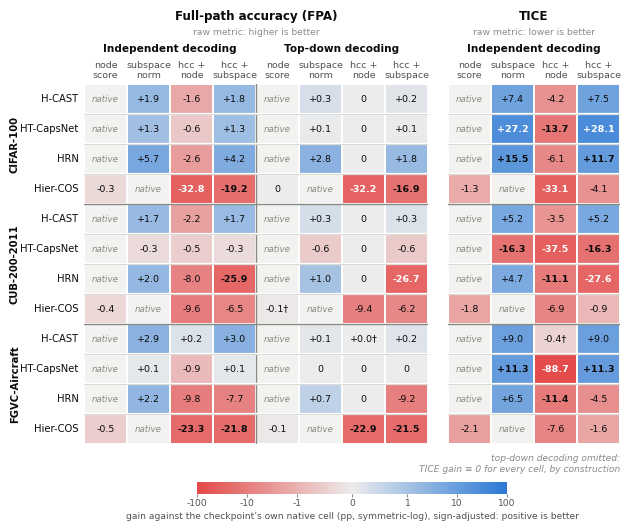


% ---- LaTeX ----------------------------------------------------
\begin{figure}[tbp]
  \centering
  \includegraphics[width=\textwidth]{figures/effect_grid}
  \caption{Post-hoc inference grid. Each tile is the mean gain over 1–3 seeds of one readout$\times$transform cell against the same checkpoint's own native readout, sign-adjusted so that positive always means better, including for the lower-is-better TICE. Colour is symmetric-log with a linear region of $\pm1$~pp, so a $1$~pp effect stays visible next to a $30$~pp collapse; read the printed numbers for exact values. \emph{native} marks the cell that is $0$ by definition, and $\dagger$ marks an effect whose sign is not the same for every seed. Each decoder is read from its own validation-selected checkpoint.}
  \label{fig:posthoc-effect-grid}
\end{figure}


**What each inference cell trades: consistency against accuracy**  
datasets: CIFAR-100, CUB-200, Aircraft · rows: H-CAST, HT-CapsNet, HRN, Hier-COS · independent decoding

[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/baseline/accuracy_consistency_map.pdf
[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/baseline/accuracy_consistency_map.png


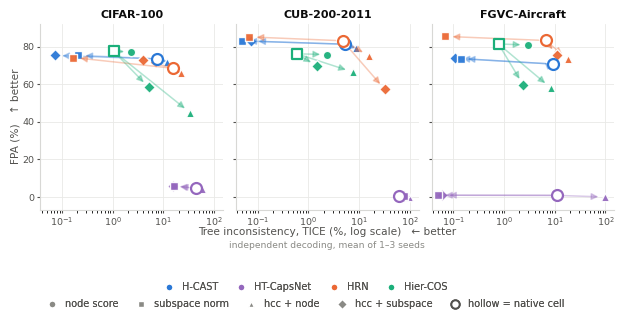


% ---- LaTeX ----------------------------------------------------
\begin{figure}[tbp]
  \centering
  \includegraphics[width=\textwidth]{figures/accuracy_consistency_map}
  \caption{What each inference cell trades. Absolute test TICE (horizontal, log scale, lower is better) against full-path accuracy (vertical, higher is better) under independent decoding, averaged over 1–3 seeds. Each arrow starts at the checkpoint's own native readout (hollow marker) and ends at one alternative cell, so up-and-left is a free win, straight left buys consistency at no accuracy cost, and downward movement is an accuracy loss. Top-down decoding is omitted because it is consistent by construction (TICE $\equiv 0$); TICE values below 0.05\% are clamped to the axis floor so that they remain visible on the log scale.}
  \label{fig:posthoc-accuracy-consistency}
\end{figure}
Relative gain of top-down over independent decoding (test FPA; per-seed 100*(td-ind)/ind, mean ± sample SD):


,dataset,model,readout,independent FPA %,independent SD,top-down FPA %,top-down − independent (pp),relative gain %,relative SD,seeds,same sign in every seed,weak_baseline
0,cifar-100,hcast,node_score,73.477,0.187,75.010,1.533,2.088,0.496,3,True,False
1,cifar-100,ht_capsnet,node_score,4.660,NaN,6.320,1.660,35.622,NaN,1,True,True
2,cifar-100,hrn,node_score,68.450,0.108,71.407,2.957,4.319,0.306,3,True,False
3,cifar-100,hiercos,node_score,77.213,0.132,77.737,0.523,0.678,0.073,3,True,False
4,cub-200-2011,hcast,node_score,81.268,0.329,82.683,1.415,1.742,0.327,3,True,False
5,cub-200-2011,ht_capsnet,node_score,0.604,NaN,1.381,0.777,128.571,NaN,1,True,True
6,cub-200-2011,hrn,node_score,83.103,0.688,84.012,0.909,1.098,0.842,3,True,False
7,cub-200-2011,hiercos,node_score,75.785,0.458,76.130,0.345,0.455,0.080,3,True,False
8,fgvc-aircraft,hcast,node_score,70.727,1.035,73.467,2.740,3.879,0.841,3,True,False
9,fgvc-aircraft,ht_capsnet,node_score,0.870,NaN,1.140,0.270,31.034,NaN,1,True,True


**What top-down decoding buys under the node score readout**  
datasets: CIFAR-100, CUB-200, Aircraft · rows: H-CAST, HT-CapsNet, HRN, Hier-COS · relative FPA change, paired per seed

[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/baseline/decoder_gain_node_score.pdf
[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/baseline/decoder_gain_node_score.png


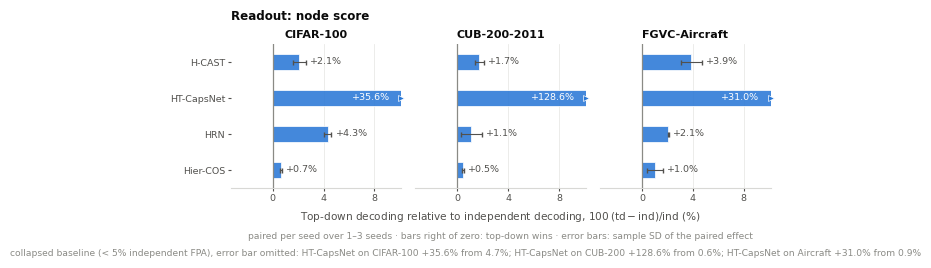


% ---- LaTeX ----------------------------------------------------
\begin{figure}[tbp]
  \centering
  \includegraphics[width=\textwidth]{figures/decoder_gain_node_score}
  \caption{Relative gain of top-down over independent decoding under the untransformed node score readout. Each bar is $100\,(\mathrm{FPA}_{\text{top-down}} - \mathrm{FPA}_{\text{independent}}) / \mathrm{FPA}_{\text{independent}}$, formed per seed and then averaged over 1–3 seeds; error bars are the sample standard deviation of that paired per-seed effect and $\dagger$ marks an effect whose sign is not the same for every seed. The quantity is a relative change, not a percentage-point difference, so the same bar length means the same fraction of full paths recovered at every absolute accuracy level. The two readout figures share one horizontal range and are directly comparable. Each decoder is read from its own validation-selected checkpoint. TICE is not shown because top-down decoding makes it identically zero by const

**What top-down decoding buys under the subspace norm readout**  
datasets: CIFAR-100, CUB-200, Aircraft · rows: H-CAST, HT-CapsNet, HRN, Hier-COS · relative FPA change, paired per seed

[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/baseline/decoder_gain_subspace_norm.pdf
[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/baseline/decoder_gain_subspace_norm.png


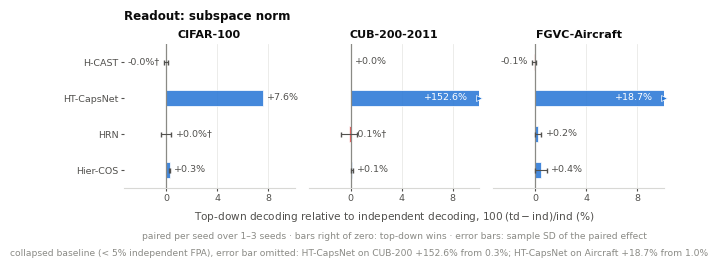


% ---- LaTeX ----------------------------------------------------
\begin{figure}[tbp]
  \centering
  \includegraphics[width=\textwidth]{figures/decoder_gain_subspace_norm}
  \caption{Relative gain of top-down over independent decoding under the untransformed subspace norm readout. Each bar is $100\,(\mathrm{FPA}_{\text{top-down}} - \mathrm{FPA}_{\text{independent}}) / \mathrm{FPA}_{\text{independent}}$, formed per seed and then averaged over 1–3 seeds; error bars are the sample standard deviation of that paired per-seed effect and $\dagger$ marks an effect whose sign is not the same for every seed. The quantity is a relative change, not a percentage-point difference, so the same bar length means the same fraction of full paths recovered at every absolute accuracy level. The two readout figures share one horizontal range and are directly comparable. Each decoder is read from its own validation-selected checkpoint. TICE is not shown because top-down decoding makes it identically zero by

**Best inference cell across every model (FPA)**  
datasets: CIFAR-100, CUB-200, Aircraft · rows: H-CAST, HT-CapsNet, HRN, Hier-COS · independent decoding

[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/baseline/best_cell_fpa_independent.pdf
[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/baseline/best_cell_fpa_independent.png


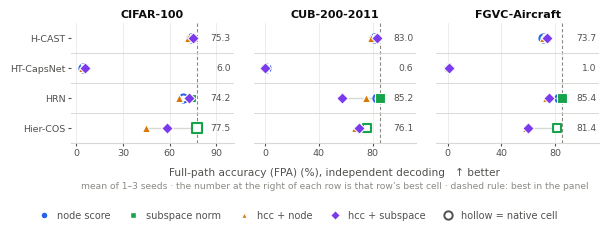


% ---- LaTeX ----------------------------------------------------
\begin{figure}[tbp]
  \centering
  \includegraphics[width=\textwidth]{figures/best_cell_fpa_independent}
  \caption{Every inference cell of every model, FPA under independent decoding, mean over 1–3 seeds. Each row is one model and carries all four readout$\times$transform cells; the hollow marker is the cell that reproduces that checkpoint's own inference and the dashed rule marks the best value in the panel. Each dataset panel has its own horizontal range, because absolute levels are not comparable across datasets.}
  \label{fig:posthoc-best-inference-fpa}
\end{figure}


In [7]:
GRID_METRICS = ('fpa', 'tice')          # any subset of posthoc.METRIC_SPECS

if absolute_summary.empty:
    print('Nothing to plot for the current selection.')
else:
    if SAVE_PLOTS:
        PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    def path(name):
        return (PLOT_OUTPUT_DIR / f'{name}.pdf') if SAVE_PLOTS else None

    posthoc.effect_grid(gain_summary, paired, absolute_summary,
                        metrics=GRID_METRICS, save_path=path('effect_grid'))
    posthoc.accuracy_consistency_map(absolute_summary,
                                     save_path=path('accuracy_consistency_map'))

    datasets = [d for d in posthoc.DATASET_ORDER if d in set(view['dataset'])]
    series = posthoc.order_series(set(view['series']))
    decoder_summary = posthoc.relative_decoder_gains(results_long, datasets=datasets,
                                                     series=series)
    if not decoder_summary.empty:
        print('Relative gain of top-down over independent decoding '
              '(test FPA; per-seed 100*(td-ind)/ind, mean ± sample SD):')
        display(decoder_summary.rename(columns={
            'inference': 'readout', 'series': 'model',
            'independent_fpa': 'independent FPA %', 'independent_std': 'independent SD',
            'topdown_fpa': 'top-down FPA %', 'delta_pp': 'top-down − independent (pp)',
            'relative_gain': 'relative gain %', 'relative_std': 'relative SD',
            'sign_agrees': 'same sign in every seed'}).round(3))
        # one shared x range, so the two readout figures are directly comparable
        shared_xlim = posthoc.relative_gain_limits(decoder_summary)
        for readout in posthoc.READOUT_LABELS:
            posthoc.decoder_gain_figure(decoder_summary, readout, datasets=datasets,
                                        series=series, xlim=shared_xlim,
                                        save_path=path(f'decoder_gain_{readout}'))

    posthoc.best_inference_chart(absolute_summary, metric='fpa',
                                 decoder=BEST_CHART_DECODER,
                                 save_path=path(f'best_cell_fpa_{BEST_CHART_DECODER}'))

## Raw values behind the gains

The figures above are all *differences* — against the native cell, or between decoders. The grid
below is the same table in raw test units, so an effect can be read against the level it sits on
and against the other models on the same dataset.

[note] 12 columns need 6.48 in; at width=\textwidth LaTeX scales it to 97%.


**Raw test values of every inference cell**  
datasets: CIFAR-100, CUB-200, Aircraft · rows: H-CAST, HT-CapsNet, HRN, Hier-COS · independent and top-down decoding · metrics: FPA, TICE

[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/baseline/absolute_grid.pdf
[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/baseline/absolute_grid.png


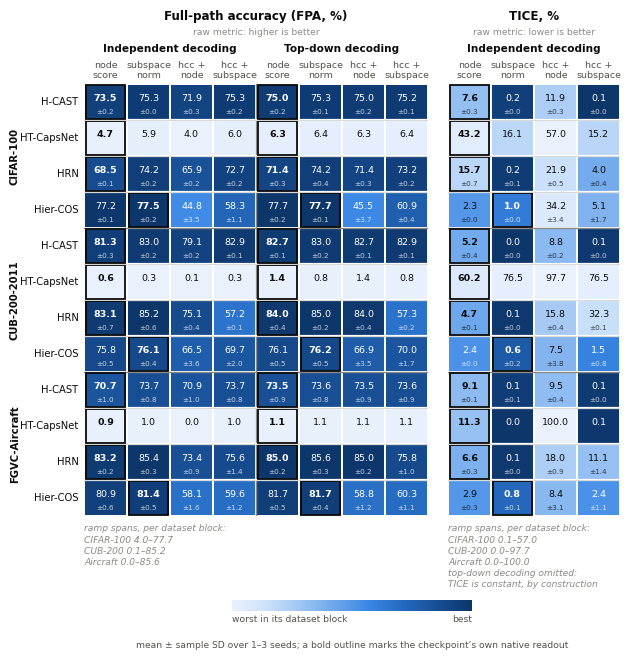


% ---- LaTeX ----------------------------------------------------
\begin{figure}[tbp]
  \centering
  \includegraphics[width=\textwidth]{figures/absolute_grid}
  \caption{Absolute post-hoc test values: every readout$\times$transform cell for every row, mean $\pm$ sample standard deviation over 1–3 seeds, each decoder read from its own validation-selected checkpoint. Shading is normalised separately inside each dataset block, because absolute levels are not comparable across datasets, and is direction-adjusted so that darker is always better; the span of every ramp is printed under the panel and the exact value in every tile. A bold outline marks the cell that reproduces the checkpoint's own inference.}
  \label{fig:posthoc-absolute-grid}
\end{figure}

Best cell per (dataset, model), by FPA under independent decoding:


,dataset,model,best_family,best_inference,best_value,best_std,native_inference,native_value,margin,runner_up,runner_up_family,seeds
0,cifar-100,hcast,baseline,subspace_norm,75.343333,0.046188,node_score,73.476667,0.063333,hcc_subspace_norm,baseline,3
1,cifar-100,hiercos,baseline,subspace_norm,77.520000,0.156205,subspace_norm,77.520000,0.306667,node_score,baseline,3
2,cifar-100,hrn,baseline,subspace_norm,74.196667,0.215484,node_score,68.450000,1.516667,hcc_subspace_norm,baseline,3
3,cifar-100,ht_capsnet,baseline,hcc_subspace_norm,5.970000,NaN,node_score,4.660000,0.040000,subspace_norm,baseline,1
4,cub-200-2011,hcast,baseline,subspace_norm,83.016914,0.150462,node_score,81.267978,0.092049,hcc_subspace_norm,baseline,3
5,cub-200-2011,hiercos,baseline,subspace_norm,76.147739,0.423819,subspace_norm,76.147739,0.362444,node_score,baseline,3
6,cub-200-2011,hrn,baseline,subspace_norm,85.151306,0.573031,node_score,83.103210,2.048096,node_score,baseline,3
7,cub-200-2011,ht_capsnet,baseline,node_score,0.604073,NaN,node_score,0.604073,0.276148,hcc_subspace_norm,baseline,1
8,fgvc-aircraft,hcast,baseline,hcc_subspace_norm,73.727373,0.788305,node_score,70.727073,0.060006,subspace_norm,baseline,3
9,fgvc-aircraft,hiercos,baseline,subspace_norm,81.398140,0.523120,subspace_norm,81.398140,0.540054,node_score,baseline,3


In [8]:
ABS_GRID_METRICS = GRID_METRICS      # any subset of posthoc.METRIC_SPECS
ABS_SHOW_SPREAD = True               # print the sample SD under each mean
# 'dataset' compares every model on the same dataset, which is the comparison the
# gain grid cannot make; 'row' rescales inside each model, which separates cells a
# collapsed model would otherwise flatten; 'panel' puts everything on one ramp.
ABS_SHADE_SCOPE = 'dataset'

if absolute_summary.empty:
    print('Nothing to plot for the current selection.')
else:
    posthoc.absolute_grid(absolute_summary, metrics=ABS_GRID_METRICS,
                          show_spread=ABS_SHOW_SPREAD, shade_scope=ABS_SHADE_SCOPE,
                          save_path=path('absolute_grid'))

    print(f'\nBest cell per (dataset, model), by FPA under {posthoc.DECODER_SHORT[BEST_CHART_DECODER]} decoding:')
    display(posthoc.best_cells(absolute_summary, metric='fpa',
                               decoder=BEST_CHART_DECODER))

## Reading the results

Two structural facts are properties of the inference rules, not results, and both have to be held
onto before any tile is interpreted:

- `hcc_node_score` shifts every sibling group by a single constant, so for a signed readout it
  **cannot change any top-down metric** — expect exactly zero gain there for H-CAST, HT-CapsNet and
  HRN, and read only the independent-decoding row. It does move both decoders for Hier-COS, whose
  readout takes the coordinate's magnitude.
- `subspace_norm` squares its inputs, so it discards the sign of whatever it aggregates. In the
  default `probability` space that is harmless — the aggregated values are already non-negative
  evidence, and a confidently rejected class contributes ~0. In the `coordinate` space the sign is
  genuinely lost, which **inverts** the evidence for a sigmoid/BCE head such as HRN's levels 0-1,
  because BCE drives non-target logits to large negative values. Two further properties are worth
  holding onto in either space: a node's own subspace grows with its descendant count, so the coarse
  score carries a `sqrt(fanout)` bias, while a **leaf's** subspace is exactly
  `{coarse parent, mid parent, self}` and so injects ancestor evidence with no fanout term at all.

What this notebook can and cannot support:

- It **can** say whether a post-hoc readout beats what these checkpoints already do, per dataset,
  decoder and seed, because that comparison is within-checkpoint.
- It **cannot** say whether this mechanism beats another one. Every gain here is measured against a
  different zero point per mechanism, so two notebooks' numbers are not on a common scale. Use
  [`all_mechanics.ipynb`](all_mechanics.ipynb) for that, and read the caveat it prints.
- If gains vary strongly by dataset, decoder or seed, report the dependence instead of claiming a
  general mechanism.